In [1]:
from sklearn.datasets import make_classification
import numpy as np
X , y = make_classification(n_samples =100, n_features = 2 , n_informative = 1 , n_redundant = 0,
                            n_classes = 2, n_clusters_per_class = 1 , random_state = 41, hypercube = False , class_sep = 10)


In [3]:
import matplotlib.pyplot as plt

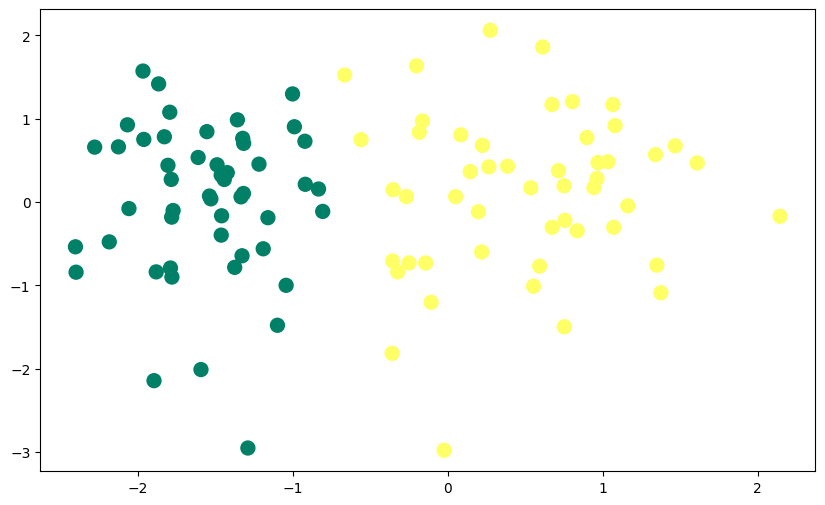

In [8]:
plt.figure(figsize = (10,6))
plt.scatter(X[:,0] ,X[: , 1] , c= y , cmap = 'summer' , s = 100)

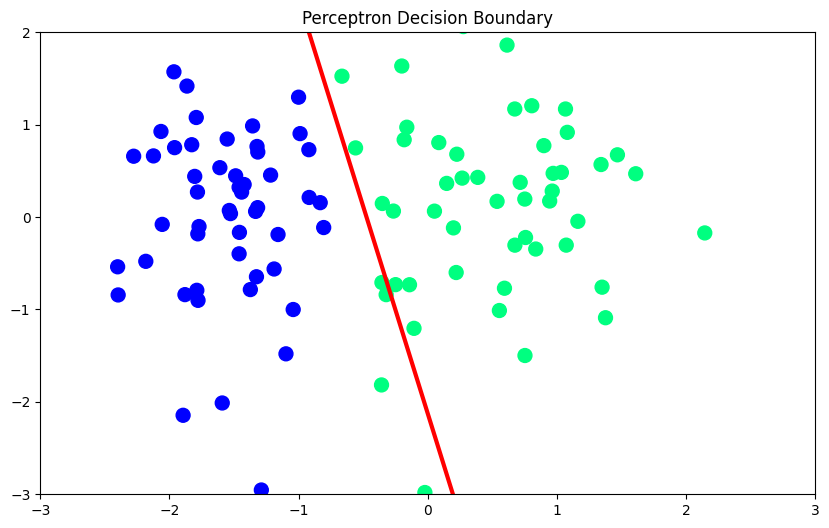

In [27]:
def perceptron(X, y):
    X = np.insert(X, 0, 1, axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(1000):
        j = np.random.randint(0, X.shape[0])

        y_hat = np.sign(np.dot(X[j], weights))
        weights = weights + lr * (y[j] - y_hat) * X[j]

    return weights[0], weights[1:]


# Train model
intercept_, coef_ = perceptron(X, y)

# ---- Plot ----
plt.figure(figsize=(10,6))

# scatter points
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', s=100)

# decision boundary
x_vals = np.linspace(-3, 3, 100)

if coef_[1] != 0:
    y_vals = -(intercept_ + coef_[0]*x_vals) / coef_[1]
    plt.plot(x_vals, y_vals, color='red', linewidth=3)

plt.ylim(-3, 2)
plt.xlim(-3, 3)

plt.title("Perceptron Decision Boundary")
plt.show()

In [29]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [31]:
ani = FuncAnimation(fig, update, frames=100, interval=200)

HTML(ani.to_jshtml())